# 04 — False-Positive & Error Analysis

**Objective:** understand *why* legitimate transactions get flagged as fraud (false positives) and *what kind* of fraud slips through (false negatives) - treated as a core modeling task, not just a false-positive-rate number, per the project's core focus on minimizing false positives.

Uses the Random Forest model at the Stage 5 operating threshold (0.12), on the validation split. Loads the persisted model/preprocessor from Stage 5/6 instead of retraining.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import preprocessing as pp

sns.set_style('whitegrid')
DATA_DIR = '../data'
MODELS_DIR = '../models'
THRESHOLD = 0.12

In [2]:
train_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTrain.csv'))
_, val_split = pp.temporal_train_val_split(train_raw, val_weeks=6)

X_val, y_val = pp.split_X_y(val_split)

preprocessor = joblib.load(f'{MODELS_DIR}/preprocessor.pkl')
rf_model = joblib.load(f'{MODELS_DIR}/random_forest.pkl')

Xt_val = preprocessor.transform(X_val)
risk_score = rf_model.predict_proba(Xt_val)[:, 1]
predicted = (risk_score >= THRESHOLD).astype(int)

print('Validation set:', len(val_split), 'transactions,', y_val.sum(), 'actual fraud')
print('Flagged at threshold', THRESHOLD, ':', predicted.sum())

Validation set: 111581 transactions, 669 actual fraud
Flagged at threshold 0.12 : 1139


## Build the error-analysis dataframe

In [3]:
err = val_split.reset_index(drop=True).copy()
err['risk_score'] = risk_score
err['predicted'] = predicted

def classify(row):
    if row['is_fraud'] == 1 and row['predicted'] == 1:
        return 'TP'
    if row['is_fraud'] == 0 and row['predicted'] == 1:
        return 'FP'
    if row['is_fraud'] == 1 and row['predicted'] == 0:
        return 'FN'
    return 'TN'

err['outcome'] = err.apply(classify, axis=1)
print(err['outcome'].value_counts())

outcome
TN    110387
TP       614
FP       525
FN        55
Name: count, dtype: int64


## False positives: are they concentrated among high-value transactions?

In [4]:
print(err.groupby('outcome')['amt'].describe()[['count', 'mean', '50%', 'std', 'max']])

            count        mean     50%         std       max
outcome                                                    
FN           55.0   93.675455   19.42  213.003900    939.56
FP          525.0  367.013524  111.60  528.148485   6438.07
TN       110387.0   66.219020   47.29  167.063049  27119.77
TP          614.0  583.706303  712.10  377.776047   1376.04


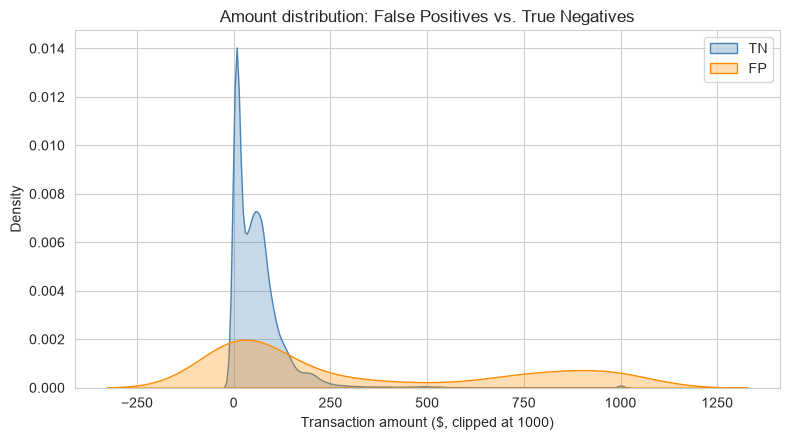

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for outcome, color in [('TN', 'steelblue'), ('FP', 'darkorange')]:
    sns.kdeplot(err.loc[err['outcome'] == outcome, 'amt'].clip(upper=1000), label=outcome, color=color, fill=True, alpha=0.3, ax=ax)
ax.set_xlabel('Transaction amount ($, clipped at 1000)')
ax.set_title('Amount distribution: False Positives vs. True Negatives')
ax.legend()
plt.tight_layout()
plt.show()

## False positives: concentrated in particular categories or time periods?

In [6]:
fp_rate_by_category = err.groupby('category').apply(
    lambda d: pd.Series({
        'n_legit': (d['is_fraud'] == 0).sum(),
        'n_fp': ((d['is_fraud'] == 0) & (d['predicted'] == 1)).sum(),
    }),
    include_groups=False,
)
fp_rate_by_category['fp_rate_pct'] = 100 * fp_rate_by_category['n_fp'] / fp_rate_by_category['n_legit']
fp_rate_by_category.sort_values('fp_rate_pct', ascending=False)

,n_legit,n_fp,fp_rate_pct
category,,,
grocery_net,3949,34,0.860977
shopping_net,8292,61,0.735649
misc_net,5500,40,0.727273
kids_pets,9695,68,0.701392
travel,3429,24,0.699913
personal_care,7796,51,0.654182
shopping_pos,10005,64,0.639680
misc_pos,6840,40,0.584795
food_dining,7736,38,0.491210


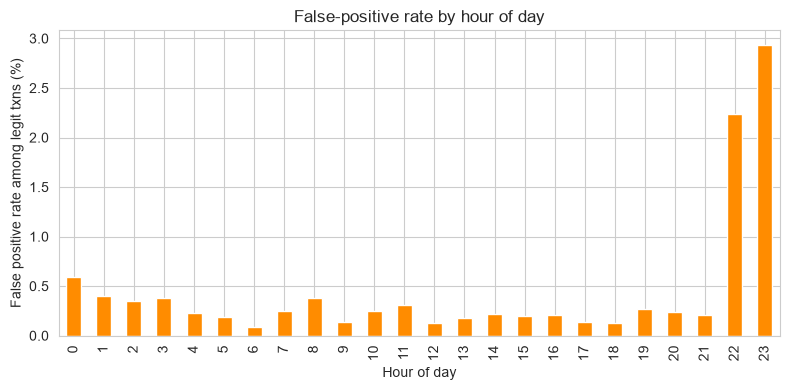

In [7]:
fp_by_hour = err.groupby('hour').apply(
    lambda d: pd.Series({
        'n_legit': (d['is_fraud'] == 0).sum(),
        'n_fp': ((d['is_fraud'] == 0) & (d['predicted'] == 1)).sum(),
    }),
    include_groups=False,
)
fp_by_hour['fp_rate_pct'] = 100 * fp_by_hour['n_fp'] / fp_by_hour['n_legit']

fig, ax = plt.subplots(figsize=(8, 4))
fp_by_hour['fp_rate_pct'].plot(kind='bar', ax=ax, color='darkorange')
ax.set_ylabel('False positive rate among legit txns (%)')
ax.set_xlabel('Hour of day')
ax.set_title('False-positive rate by hour of day')
plt.tight_layout()
plt.show()

## Which features distinguish FP from TN, and FP from TP?

In [8]:
compare_cols = ['amt', 'age', 'city_pop', 'merchant_distance_km', 'hour']
print('FP vs TN (why legit transactions get flagged):')
print(err[err['outcome'].isin(['FP', 'TN'])].groupby('outcome')[compare_cols].mean().round(2))
print()
print('FP vs TP (what makes a false alarm look like real fraud):')
print(err[err['outcome'].isin(['FP', 'TP'])].groupby('outcome')[compare_cols].mean().round(2))

FP vs TN (why legit transactions get flagged):
            amt    age  city_pop  merchant_distance_km   hour
outcome                                                      
FP       367.01  42.27  79808.23                 75.79  17.03
TN        66.22  46.04  87945.49                 76.15  12.78

FP vs TP (what makes a false alarm look like real fraud):
            amt    age  city_pop  merchant_distance_km   hour
outcome                                                      
FP       367.01  42.27  79808.23                 75.79  17.03
TP       583.71  50.25  33410.62                 76.80  14.35


## False negatives: what fraud does the model miss?

In [9]:
print('FN vs TP (missed fraud vs. caught fraud):')
print(err[err['outcome'].isin(['FN', 'TP'])].groupby('outcome')[compare_cols].mean().round(2))
print()
print('FN by category:')
print(err[err['outcome'].isin(['FN', 'TP'])].groupby(['category', 'outcome']).size().unstack(fill_value=0))

FN vs TP (missed fraud vs. caught fraud):
            amt    age  city_pop  merchant_distance_km   hour
outcome                                                      
FN        93.68  43.22  43751.76                 74.68  18.69
TP       583.71  50.25  33410.62                 76.80  14.35

FN by category:
outcome         FN   TP
category               
entertainment    0   18
food_dining      5    6
gas_transport    0   56
grocery_net      1    8
grocery_pos      0  144
health_fitness   8    9
home             2   16
kids_pets       11    9
misc_net         3   91
misc_pos         4   22
personal_care   14    8
shopping_net     0  151
shopping_pos     1   74
travel           6    2


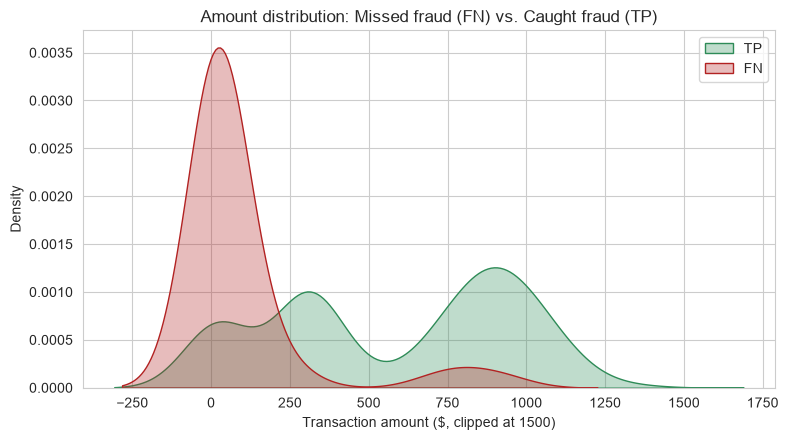

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for outcome, color in [('TP', 'seagreen'), ('FN', 'firebrick')]:
    sns.kdeplot(err.loc[err['outcome'] == outcome, 'amt'].clip(upper=1500), label=outcome, color=color, fill=True, alpha=0.3, ax=ax)
ax.set_xlabel('Transaction amount ($, clipped at 1500)')
ax.set_title('Amount distribution: Missed fraud (FN) vs. Caught fraud (TP)')
ax.legend()
plt.tight_layout()
plt.show()

## How does the threshold affect the error mix?

Comparing the Stage 5 operating threshold (0.12) against a stricter one (0.5, the naive default) and the near-tied XGBoost threshold (0.68) for reference - not to re-litigate Stage 5's choice, but to show concretely how the FP/FN balance shifts.

In [11]:
for t in [0.12, 0.5, 0.9]:
    pred_t = (risk_score >= t).astype(int)
    tp = int(((y_val == 1) & (pred_t == 1)).sum())
    fp = int(((y_val == 0) & (pred_t == 1)).sum())
    fn = int(((y_val == 1) & (pred_t == 0)).sum())
    tn = int(((y_val == 0) & (pred_t == 0)).sum())
    print(f'threshold={t:.2f}  TP={tp:4d}  FP={fp:4d}  FN={fn:4d}  TN={tn:6d}')

threshold=0.12  TP= 614  FP= 525  FN=  55  TN=110387
threshold=0.50  TP= 560  FP=  57  FN= 109  TN=110855
threshold=0.90  TP= 392  FP=   2  FN= 277  TN=110910


## Summary of error-analysis findings

At threshold 0.12: 614 true positives, 525 false positives, 55 false negatives, 110,387 true negatives.

**False positives ARE concentrated among higher-value transactions:** mean amount $367.01 (median $111.60) vs. $66.22 (median $47.29) for true negatives - confirming the pattern the project plan asked us to check for, not just assumed.

**False positives cluster in card-not-present-style categories:** `grocery_net` (0.86% FP rate), `shopping_net` (0.74%), `misc_net` (0.73%), `kids_pets` (0.70%), and `travel` (0.70%) have the highest false-positive rates, while `grocery_pos` (0.09%) and `gas_transport` (0.13%) have the lowest. This lines up with Stage 1's EDA finding that these same online (`_net`) categories carry the highest real fraud rates - the model is picking up a genuine category-level signal, it's just not perfectly precise about it.

**FP vs. TN:** false positives skew toward higher amounts, later hours (17.0 vs. 12.8 average), and lower `city_pop` - i.e., legitimate transactions that *look* like fraud on the features the model uses. `merchant_distance_km` shows no separation here either (75.8 vs. 76.2), consistent with Stage 1.

**FP vs. TP:** false positives are high-amount but not *as* high as real fraud ($367 vs. $584 mean), and occur in noticeably denser areas (`city_pop` 79,808 vs. 33,410) - genuine fraud in this dataset skews toward less populous areas, a pattern the model has partly learned but doesn't fully separate on amount and city_pop alone.

**What fraud does the model miss (FN vs. TP):** missed fraud is dramatically lower-amount ($93.68 vs. $583.71 mean) and skews later in the day (18.7 vs. 14.4 average hour). By category, the model has perfect or near-perfect recall on `grocery_pos`, `shopping_net`, `gas_transport`, and `entertainment` (0 missed each), but actually **misses more fraud than it catches** in `kids_pets` (11 FN vs. 9 TP), `personal_care` (14 FN vs. 8 TP), and `travel` (6 FN vs. 2 TP) - all lower-typical-amount categories. The model has effectively learned 'high amount + certain categories = fraud' and is weakest exactly where fraud doesn't announce itself with a large amount.

**Threshold sensitivity, in raw counts:** at 0.12, 525 FPs buy 614 TPs (55 FN); at 0.50, FPs drop to 57 but FN nearly doubles to 109; at 0.90, FPs nearly vanish (2) but FN triples to 277. There's no threshold that removes both kinds of error - Stage 5's choice of 0.12 explicitly accepts more false positives (mostly higher-value, explainable-looking transactions) in exchange for catching fraud that a stricter threshold would let through, particularly the lower-amount fraud this section shows the model already struggles with.

**Implication for Stage 9 (fraud rules):** amount and category are real, usable signals for investigator-facing rules; `merchant_distance_km` is not, on this dataset (confirmed twice now, in EDA and here). A simple 'flag if amount is unusually high for this category' rule would catch much of what the model catches, but would inherit the same blind spot on low-amount fraud.